<a href="https://colab.research.google.com/github/Afrin-mte/OIBSIP/blob/main/Task_01_(Dataset_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **McDonald's Menu — Exploratory Data Analysis**
**Data Loading & Cleaning → Descriptive Statistics → Trend Analysis → Product Analysis → Visualization → Recommendations**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style="whitegrid")

**Loading the Dataset and reading Columns and Rows**

In [4]:
df=pd.read_csv('menu.csv')
df.head()

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


**Finding missing values**

In [7]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    object 
 1   Item                           260 non-null    object 
 2   Serving Size                   260 non-null    object 
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260 non-null    int

**Basic Statistical Summary for numerical columns**

In [8]:
print(df.describe())

          Calories  Calories from Fat   Total Fat  Total Fat (% Daily Value)  \
count   260.000000         260.000000  260.000000                 260.000000   
mean    368.269231         127.096154   14.165385                  21.815385   
std     240.269886         127.875914   14.205998                  21.885199   
min       0.000000           0.000000    0.000000                   0.000000   
25%     210.000000          20.000000    2.375000                   3.750000   
50%     340.000000         100.000000   11.000000                  17.000000   
75%     500.000000         200.000000   22.250000                  35.000000   
max    1880.000000        1060.000000  118.000000                 182.000000   

       Saturated Fat  Saturated Fat (% Daily Value)   Trans Fat  Cholesterol  \
count     260.000000                     260.000000  260.000000   260.000000   
mean        6.007692                      29.965385    0.203846    54.942308   
std         5.321873                   

**Comparing the Calories across different Menu Categories**

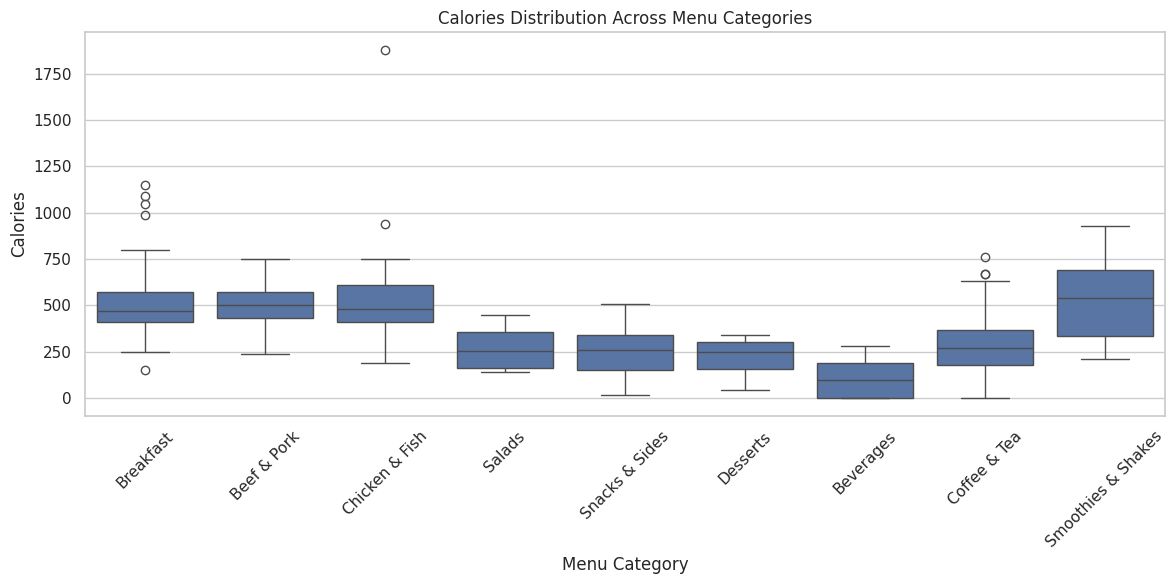

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='Calories', data=df)
plt.title('Calories Distribution Across Menu Categories')
plt.xlabel('Menu Category')
plt.ylabel('Calories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Calorie Distribution in Small, Medium, and Large Drinks**

/tmp/ipykernel_6632/292067371.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Size', y='Calories', data=df_drinks, order=['Small', 'Medium', 'Large'], palette='muted')


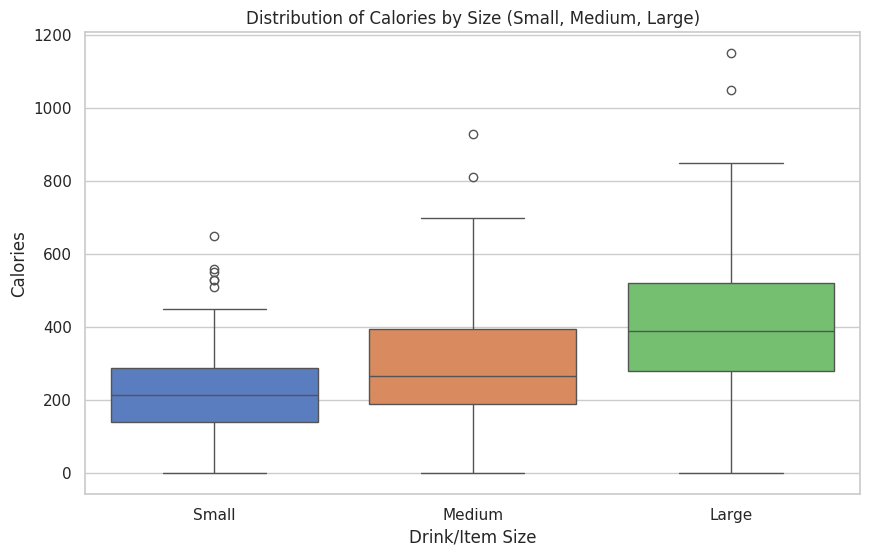

In [10]:

df_drinks = df[df['Item'].str.contains('Small|Medium|Large', na=False, case=False)].copy()

df_drinks['Size'] = df_drinks['Item'].str.extract(r'(Small|Medium|Large)', expand=False)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Size', y='Calories', data=df_drinks, order=['Small', 'Medium', 'Large'], palette='muted')
plt.title('Distribution of Calories by Size (Small, Medium, Large)')
plt.xlabel('Drink/Item Size')
plt.ylabel('Calories')
plt.show()

**Determining Highest Correlations**

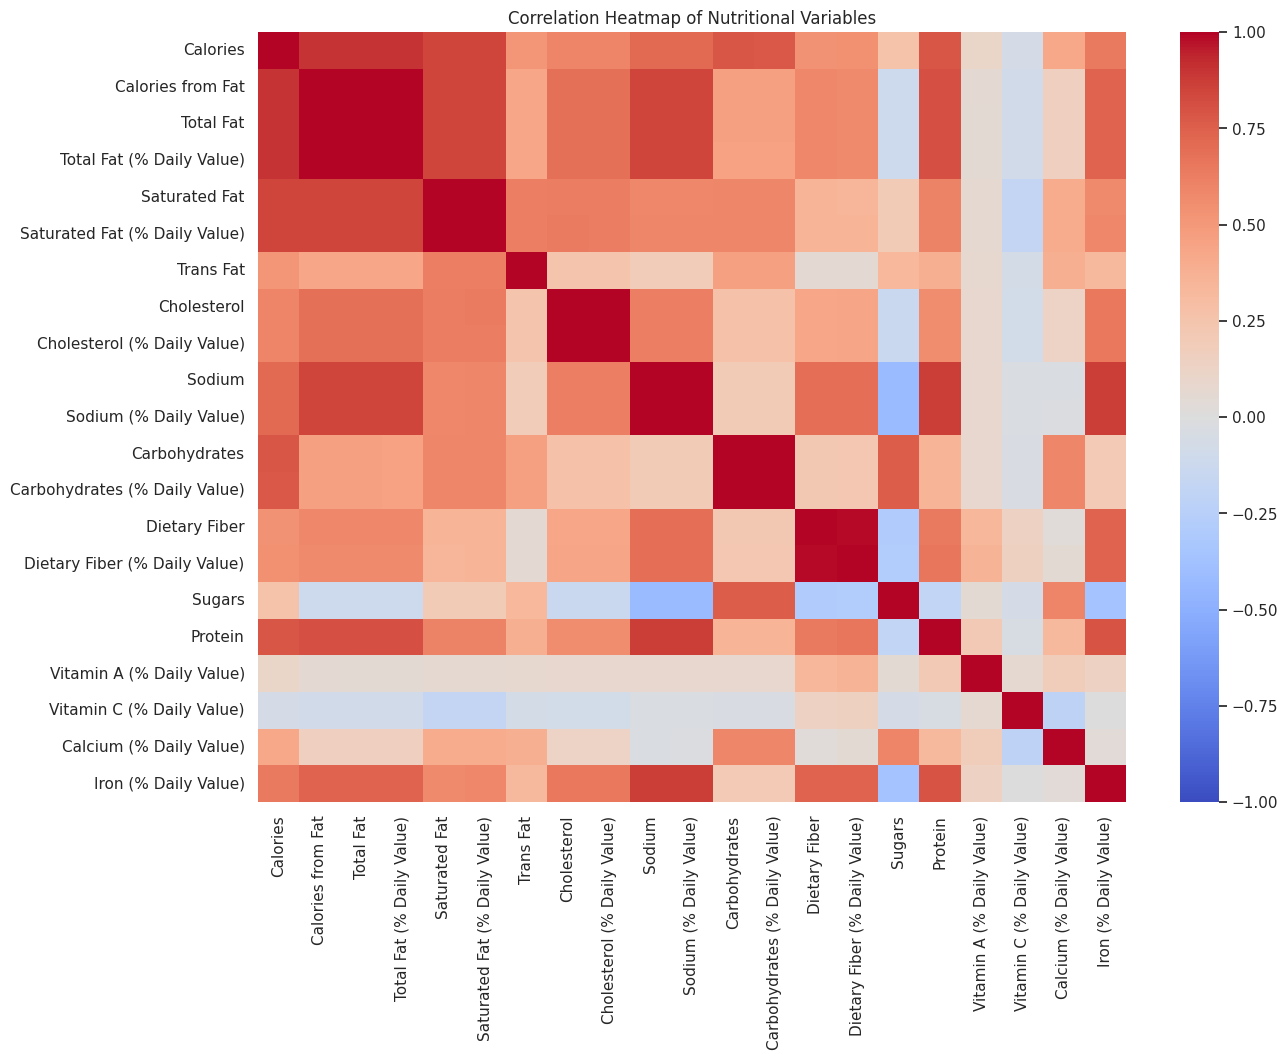


 Highest Correlated Variables

Top 5 Highest Positive Correlations:
Dietary Fiber (% Daily Value)  Dietary Fiber           0.986350
Calories from Fat              Calories                0.904588
Calories                       Total Fat               0.904409
Total Fat (% Daily Value)      Calories                0.904123
Sodium                         Iron (% Daily Value)    0.871593
dtype: float64


In [13]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Nutritional Variables')
plt.show()

print("\n Highest Correlated Variables\n")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 0.99].drop_duplicates()

print("Top 5 Highest Positive Correlations:")
print(corr_pairs.head(5))

**Calorie Distribution Across Categories**

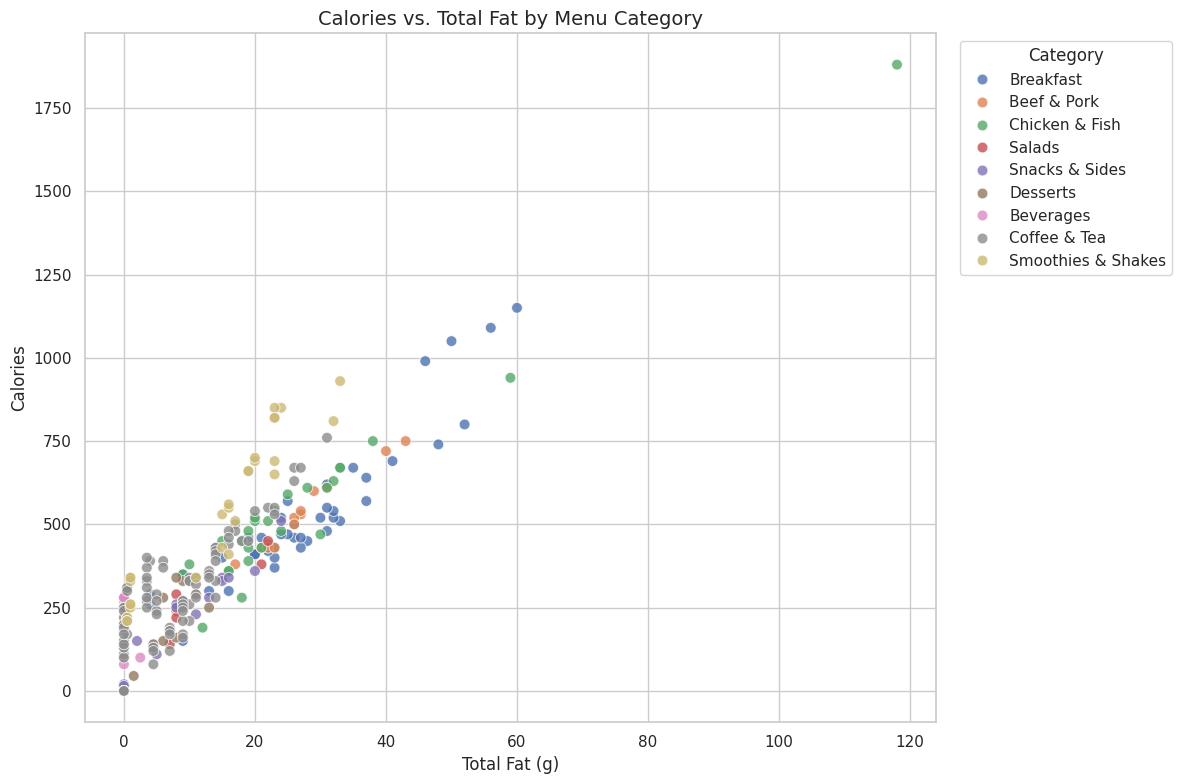

In [14]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Total Fat', y='Calories', hue='Category', data=df, alpha=0.8, s=60)

plt.title('Calories vs. Total Fat by Menu Category', fontsize=14)
plt.xlabel('Total Fat (g)', fontsize=12)
plt.ylabel('Calories', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Category')

plt.tight_layout()
plt.show()

**Recommendations**

In [16]:
def get_recommendations(df, goal):
    """
    Returns the top 3 recommended McDonald's items based on a dietary goal.
    Goals available: 'Low Calorie', 'High Protein', 'Low Fat'
    """
    print(f"Top 3 Recommendations for: {goal}\n")


    food_only = df[~df['Category'].isin(['Beverages', 'Coffee & Tea'])]

    if goal == 'Low Calorie':
        # Sort by lowest calories
        recs = food_only[['Item', 'Category', 'Calories']].sort_values(by='Calories', ascending=True).head(3)

    elif goal == 'High Protein':
        # Sort by highest protein
        recs = food_only[['Item', 'Category', 'Protein', 'Calories']].sort_values(by='Protein', ascending=False).head(3)

    elif goal == 'Low Fat':
        # Sort by lowest total fat
        recs = food_only[['Item', 'Category', 'Total Fat', 'Calories']].sort_values(by='Total Fat', ascending=True).head(3)

    else:
        return "Invalid goal. Please choose 'Low Calorie', 'High Protein', or 'Low Fat'."


    display(recs)
    print("\n")
get_recommendations(df, 'Low Calorie')
get_recommendations(df, 'High Protein')
get_recommendations(df, 'Low Fat')

Top 3 Recommendations for: Low Calorie



,Item,Category,Calories
101,Apple Slices,Snacks & Sides,15
100,Side Salad,Snacks & Sides,20
106,Kids Ice Cream Cone,Desserts,45




Top 3 Recommendations for: High Protein



,Item,Category,Protein,Calories
82,Chicken McNuggets (40 piece),Chicken & Fish,87,1880
47,Double Quarter Pounder with Cheese,Beef & Pork,48,750
81,Chicken McNuggets (20 piece),Chicken & Fish,44,940




Top 3 Recommendations for: Low Fat



,Item,Category,Total Fat,Calories
101,Apple Slices,Snacks & Sides,0.0,15
100,Side Salad,Snacks & Sides,0.0,20
232,Blueberry Pomegranate Smoothie (Small),Smoothies & Shakes,0.5,220
